In [1]:
import pandas as pd
import requests
import time
from datetime import datetime, timedelta
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="cloudburst_data_collector_v1") 

In [2]:
def get_coordinates(place):
  """Cleanly fetches Lat/Long with a fallback mechanism."""
  try:
    location = geolocator.geocode(f"{place}, India", timeout=10)
    if location:
        return location.latitude, location.longitude

    # Fallback: Try just District and State
    parts = place.split(',')
    if len(parts) >= 2:
        fallback = f"{parts[-2].strip()}, {parts[-1].strip()}, India"
        location = geolocator.geocode(fallback, timeout=10)
        if location:
            return location.latitude, location.longitude
  except Exception as e:
    print(f"Geocoding error for {place}: {e}")
  return None, None

In [3]:
def fetch_weather_range(lat, lon, start_date, end_date):
    """Fetches hourly weather for a specific date range."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,surface_pressure,cloudcover,soil_moisture_0_to_7cm",
        "timezone": "GMT"
    }

    try:
        response = requests.get(url, params=params)
        response.raise_for_status() # Check for HTTP errors
        h = response.json()["hourly"]
        return pd.DataFrame({
            "time": h["time"],
            "temp": h["temperature_2m"],
            "hum": h["relative_humidity_2m"],
            "precip": h["precipitation"],
            "press": h["surface_pressure"],
            "cloud": h["cloudcover"],
            "soil_m": h["soil_moisture_0_to_7cm"]
        })
    except Exception as e:
        print(f"API Error: {e}")
        return pd.DataFrame()


In [4]:
raw_events = [
    {"place": "Chaned (Kali Mata temple), Chamba, Himachal Pradesh", "date": "2022-05-03"},
    {"place": "Bohrakun, Nainital, Uttarakhand", "date": "2022-05-07"},
    {"place": "Papoli (Nakuri patti), Bageshwar, Uttarakhand", "date": "2022-05-10"},
    {"place": "Khadiseri village (Garsa valley), Kullu, Himachal Pradesh", "date": "2022-06-15"},
    {"place": "Hell village (Tepa panchayat), Chamba, Himachal Pradesh", "date": "2022-06-15"},
    {"place": "Changsheel Bugyal (Mori), Uttarkashi, Uttarakhand", "date": "2022-07-01"},
    {"place": "Karpat (Miyar valley), Lahaul & Spiti, Himachal Pradesh", "date": "2022-07-02"},
    {"place": "Batseri, Kinnaur, Himachal Pradesh", "date": "2022-07-02"},
    {"place": "Mori Market, Uttarkashi, Uttarakhand", "date": "2022-07-05"},
    {"place": "Chojh village (Manikaran Valley), Kullu, Himachal Pradesh", "date": "2022-07-06"},
    {"place": "Malana HEP dam site, Kullu, Himachal Pradesh", "date": "2022-07-06"},
    {"place": "Bhagot village, Bilaspur, Himachal Pradesh", "date": "2022-07-07"},
    {"place": "Amarnath Shrine (Pahalgam), Jammu and Kashmir", "date": "2022-07-08"},
    {"place": "Munar (Luhar Valley), Bageshwar, Uttarakhand", "date": "2022-07-08"},
    {"place": "Sainranthi (Munsyari), Pithoragarh, Uttarakhand", "date": "2022-07-08"},
    {"place": "Haldwani city, Nainital, Uttarakhand", "date": "2022-07-09"},
    {"place": "Shilagarh (Garsa valley), Kullu, Himachal Pradesh", "date": "2022-07-09"},
    {"place": "Lunekh village, Chamba, Himachal Pradesh", "date": "2022-07-09"},
    {"place": "Kudtha village, Chamba, Himachal Pradesh", "date": "2022-07-09"},
    {"place": "Shivan (Kumarsain), Shimla, Himachal Pradesh", "date": "2022-07-16"},
    {"place": "Gotang (Pooh), Kinnaur, Himachal Pradesh", "date": "2022-07-18"},
    {"place": "Leo Village (Pooh), Kinnaur, Himachal Pradesh", "date": "2022-07-19"},
    {"place": "Sumdo check post, Lahaul & Spiti, Himachal Pradesh", "date": "2022-07-19"},
    {"place": "Patodi tok (Joshimath), Chamoli, Uttarakhand", "date": "2022-07-20"},
    {"place": "Giu village, Lahaul & Spiti, Himachal Pradesh", "date": "2022-07-28"},
    {"place": "Karpat, Lahaul & Spiti, Himachal Pradesh", "date": "2022-07-28"},
    {"place": "Chanaighad area, Kullu, Himachal Pradesh", "date": "2022-07-28"},
    {"place": "Jhimir (Darma Valley), Pithoragarh, Uttarakhand", "date": "2022-07-30"},
    {"place": "Bhararisain, Chamoli, Uttarakhand", "date": "2022-07-30"},
    {"place": "Jogadi (Srinagar), Pauri, Uttarakhand", "date": "2022-08-01"},
    {"place": "Chhinka village (Augustmuni), Rudraprayag, Uttarakhand", "date": "2022-08-09"},
    {"place": "Agarchatti Basti (Gairsain), Chamoli, Uttarakhand", "date": "2022-08-10"},
    {"place": "Purola, Uttarkashi, Uttarakhand", "date": "2022-08-11"},
    {"place": "Gaideta village, Dehradun, Uttarakhand", "date": "2022-08-11"},
    {"place": "Sarkhet (Maldevta), Dehradun, Uttarakhand", "date": "2022-08-20"},
    {"place": "Gwad (Kumalda), Tehri, Uttarakhand", "date": "2022-08-20"},
    {"place": "Binak (Yamkeshwar), Pauri, Uttarakhand", "date": "2022-08-20"},
    {"place": "Arakot (Mori), Uttarkashi, Uttarakhand", "date": "2022-08-20"},
    {"place": "Gharad (Jakholi), Rudraprayag, Uttarakhand", "date": "2022-08-24"},
    {"place": "Chirbatiya (Ghansali), Tehri, Uttarakhand", "date": "2022-08-24"},
    {"place": "Khotila village (Dharchula), Pithoragarh, Uttarakhand", "date": "2022-09-10"},
    {"place": "Udpalta (Chakrata), Dehradun, Uttarakhand", "date": "2022-09-25"},
    {"place": "Gangtok, East Sikkim, Sikkim", "date": "2023-04-19"},
    {"place": "Bindoo Zalangam (Kokernag), Anantnag, Jammu and Kashmir", "date": "2023-05-02"},
    {"place": "Lammar Hallan, Kulgam, Jammu and Kashmir", "date": "2023-05-03"},
    {"place": "Bujbagh (Pampore), Pulwama, Jammu and Kashmir", "date": "2023-05-06"},
    {"place": "Pakyong, East Sikkim, Sikkim", "date": "2023-06-16"},
    {"place": "Kulgam district, Jammu and Kashmir", "date": "2023-07-07"},
    {"place": "Manali Valley, Kullu, Himachal Pradesh", "date": "2023-07-09"},
    {"place": "Kharyouk area, Leh, Ladakh", "date": "2023-07-09"},
    {"place": "Mandi town, Mandi, Himachal Pradesh", "date": "2023-07-10"},
    {"place": "Garsa valley, Kullu, Himachal Pradesh", "date": "2023-07-17"},
    {"place": "Gujjar Pati Zurhama, Kupwara, Jammu and Kashmir", "date": "2023-07-19"},
    {"place": "Reasi district, Jammu and Kashmir", "date": "2023-07-19"},
    {"place": "Salooni, Chamba, Himachal Pradesh", "date": "2023-07-20"},
    {"place": "Upper Leh, Leh, Ladakh", "date": "2023-07-21"},
    {"place": "Naginar (Faqir Gujri), Srinagar, Jammu and Kashmir", "date": "2023-07-22"},
    {"place": "Damhal Hanjipora, Kulgam, Jammu and Kashmir", "date": "2023-07-22"},
    {"place": "Kota Nullah, Doda, Jammu and Kashmir", "date": "2023-07-22"},
    {"place": "Kias village, Kullu, Himachal Pradesh", "date": "2023-07-22"},
    {"place": "Leh town, Leh, Ladakh", "date": "2023-07-22"},
    {"place": "Lolab valley, Kupwara, Jammu and Kashmir", "date": "2023-07-23"},
    {"place": "Gharshu village (Nichar), Kinnaur, Himachal Pradesh", "date": "2024-05-12"},
    {"place": "Kalamassery, Ernakulam, Kerala", "date": "2024-05-28"},
    {"place": "Thrikkakara, Ernakulam, Kerala", "date": "2024-05-28"},
    {"place": "Jiawala village (Arki), Solan, Himachal Pradesh", "date": "2024-06-24"},
    {"place": "Dana village (Rajpur), Sirmaur, Himachal Pradesh", "date": "2024-06-29"},
    {"place": "Talehan village (Karsog), Mandi, Himachal Pradesh", "date": "2024-07-04"},
    {"place": "Retua village (Paonta), Sirmaur, Himachal Pradesh", "date": "2024-07-20"},
    {"place": "Palchan village (Anjani Mahadev), Kullu, Himachal Pradesh", "date": "2024-07-25"},
    {"place": "Karpat village (Miyar valley), Lahaul & Spiti, Himachal Pradesh", "date": "2024-07-27"},
    {"place": "Ropa village (Pooh), Kinnaur, Himachal Pradesh", "date": "2024-07-28"},
    {"place": "Tosh village (Manikaran), Kullu, Himachal Pradesh", "date": "2024-07-30"},
    {"place": "Samej village (Rampur), Shimla, Himachal Pradesh", "date": "2024-07-31"},
    {"place": "Jhakadi area (Rampur), Shimla, Himachal Pradesh", "date": "2024-07-31"},
    {"place": "Singhgad (Kullu), Himachal Pradesh", "date": "2024-07-31"},
    {"place": "Padhar area, Mandi, Himachal Pradesh", "date": "2024-07-31"},
    {"place": "Samej Khad (Rampur), Shimla, Himachal Pradesh", "date": "2024-08-01"},
    {"place": "Jaon village (Nirmand), Kullu, Himachal Pradesh", "date": "2024-08-01"},
    {"place": "Bagipul area (Nirmand), Kullu, Himachal Pradesh", "date": "2024-08-01"},
    {"place": "Tikkan village (Padhar), Mandi, Himachal Pradesh", "date": "2024-08-01"},
    {"place": "Ghansali, Tehri Garhwal, Uttarakhand", "date": "2024-08-01"},
    {"place": "Terang village (Chauhar Valley), Mandi, Himachal Pradesh", "date": "2024-08-01"},
    {"place": "Sagnam village (Pin valley), Lahaul & Spiti, Himachal Pradesh", "date": "2024-08-02"},
    {"place": "Darcha-Shinkula road, Lahaul & Spiti, Himachal Pradesh", "date": "2024-08-02"},
    {"place": "Kedarnath Valley, Rudraprayag, Uttarakhand", "date": "2024-08-02"},
    {"place": "Chicham village (Kaza), Lahaul & Spiti, Himachal Pradesh", "date": "2024-08-04"},
    {"place": "Jobrang village (Kelang), Lahaul & Spiti, Himachal Pradesh", "date": "2024-08-04"},
    {"place": "Tarapur (Nerwa), Shimla, Himachal Pradesh", "date": "2024-08-10"},
    {"place": "Matar village (Nahan), Sirmaur, Himachal Pradesh", "date": "2024-08-10"},
    {"place": "Khab village (Pooh), Kinnaur, Himachal Pradesh", "date": "2024-08-11"},
    {"place": "Thikru village (Sangla), Kinnaur, Himachal Pradesh", "date": "2024-08-13"},
    {"place": "Damrali village (Rampur), Shimla, Himachal Pradesh", "date": "2024-08-16"},
    {"place": "Baghal village (Rampur), Shimla, Himachal Pradesh", "date": "2024-09-14"},
    {"place": "Parduni village (Paonta Sahib), Sirmaur, Himachal Pradesh", "date": "2024-09-26"},
    {"place": "Karnah (Kupwara), Jammu and Kashmir", "date": "2025-05-27"},
    {"place": "Jiwa valley (Sainj Valley), Kullu, Himachal Pradesh", "date": "2025-06-25"},
    {"place": "Sainj Valley (Parbati II & III), Kullu, Himachal Pradesh", "date": "2025-06-25"},
    {"place": "Yamunotri Highway, Uttarkashi, Uttarakhand", "date": "2025-06-29"},
    {"place": "Gudah village (Bakhali khad), Mandi, Himachal Pradesh", "date": "2025-06-30"},
    {"place": "Thunag (Mandi), Himachal Pradesh", "date": "2025-07-02"},
    {"place": "Janjehli (Mandi), Himachal Pradesh", "date": "2025-07-02"},
    {"place": "Karsog (Mandi), Himachal Pradesh", "date": "2025-07-02"},
    {"place": "Gohar (Mandi), Himachal Pradesh", "date": "2025-07-02"},
    {"place": "Dharampur (Mandi), Himachal Pradesh", "date": "2025-07-02"},
    {"place": "Mandi (Seraj Valley), Mandi, Himachal Pradesh", "date": "2025-07-28"},
    {"place": "Malana stream (tributary of Parvati), Kullu, Himachal Pradesh", "date": "2025-08-01"},
    {"place": "Dharali village (Uttarkashi), Uttarakhand", "date": "2025-08-05"},
    {"place": "Sukhi Top (Uttarkashi), Uttarakhand", "date": "2025-08-05"},
    {"place": "Bankura village (Pauri Garhwal), Uttarakhand", "date": "2025-08-06"},
    {"place": "Mansari village (Pauri Garhwal), Uttarakhand", "date": "2025-08-06"},
    {"place": "Sarson village (Pauri Garhwal), Uttarakhand", "date": "2025-08-06"},
    {"place": "Katola gaad (Bankura village), Pauri, Uttarakhand", "date": "2025-08-07"},
    {"place": "Chishoti/Chashoti village, Kishtwar, Jammu and Kashmir", "date": "2025-08-14"},
    {"place": "Buner district (Jammu and Kashmir border region), Jammu and Kashmir", "date": "2025-08-15"},
    {"place": "Tharali region, Chamoli, Uttarakhand", "date": "2025-08-23"},
    {"place": "Doda district, Jammu and Kashmir", "date": "2025-08-26"},
    {"place": "Sahastradhara, Dehradun, Uttarakhand", "date": "2025-08-29"},
    {"place": "Pausari Gram Panchayat (Kapkot), Bageshwar, Uttarakhand", "date": "2025-08-29"},
    {"place": "Chennai (five separate locations), Tamil Nadu", "date": "2025-08-30"},
    {"place": "Sahastradhara, Dehradun, Uttarakhand", "date": "2025-09-15"},
    {"place": "Mussoorie, Dehradun, Uttarakhand", "date": "2025-09-15"},
    {"place": "Prem Nagar, Dehradun, Uttarakhand", "date": "2025-09-15"},
    {"place": "Sahastradhara, Dehradun, Uttarakhand", "date": "2025-09-16"},
    {"place": "Vikasnagar, Dehradun, Uttarakhand", "date": "2025-09-16"},
    {"place": "Garia, Kolkata, West Bengal", "date": "2025-09-23"},
    {"place": "Jodhpur Park, Kolkata, West Bengal", "date": "2025-09-23"},
    {"place": "Kalighat, Kolkata, West Bengal", "date": "2025-09-23"},
    {"place": "Topsia, Kolkata, West Bengal", "date": "2025-09-23"},
    {"place": "Ballygunge, Kolkata, West Bengal", "date": "2025-09-23"},
]

all_data = []

for event in raw_events:

    lat, lon = get_coordinates(event['place'])

    if lat and lon:
        print(f"Processing: {event['place']}")

        event_dt = datetime.strptime(event['date'], "%Y-%m-%d")
        year = event_dt.year

        # Fetch FULL YEAR weather data
        year_start = f"{year}-01-01"
        year_end = f"{year}-12-31"

        df = fetch_weather_range(lat, lon, year_start, year_end)

        if not df.empty:

            df["time"] = pd.to_datetime(df["time"])
            df["location"] = event["place"]

            # Default label
            df["is_event"] = 0

            # Event window (±3 hours)
            event_start = event_dt - timedelta(hours=3)
            event_end = event_dt + timedelta(hours=3)

            df.loc[
                (df["time"] >= event_start) &
                (df["time"] <= event_end),
                "is_event"
            ] = 1

            # Sort time
            df = df.sort_values("time")

            # Feature Engineering
            df['press_diff'] = df.groupby('location')['press'].diff()
            df['hum_diff'] = df.groupby('location')['hum'].diff()
            df['temp_diff'] = df.groupby('location')['temp'].diff()

            df['rain_roll3'] = df.groupby('location')['precip'].rolling(3).sum().reset_index(level=0, drop=True)
            df['rain_roll6'] = df.groupby('location')['precip'].rolling(6).sum().reset_index(level=0, drop=True)

            df['hour'] = df['time'].dt.hour
            df['month'] = df['time'].dt.month

            df = df.dropna()

            all_data.append(df)

        time.sleep(1.5)
    else:
        print(f"Skipping: {event['place']} (Coordinates not found)")


if all_data:

    dataset = pd.concat(all_data, ignore_index=True)

    print("\nDataset generation complete!")
    print("Dataset shape:", dataset.shape)
    print(dataset.head())

    dataset.to_csv("cloudburst_dataset_v3_full_year.csv", index=False)

else:
    print("No data collected.")

Processing: Chaned (Kali Mata temple), Chamba, Himachal Pradesh
Processing: Bohrakun, Nainital, Uttarakhand
Processing: Papoli (Nakuri patti), Bageshwar, Uttarakhand
Processing: Khadiseri village (Garsa valley), Kullu, Himachal Pradesh
Processing: Hell village (Tepa panchayat), Chamba, Himachal Pradesh
Processing: Changsheel Bugyal (Mori), Uttarkashi, Uttarakhand
Processing: Karpat (Miyar valley), Lahaul & Spiti, Himachal Pradesh
Processing: Batseri, Kinnaur, Himachal Pradesh
Processing: Mori Market, Uttarkashi, Uttarakhand
Processing: Chojh village (Manikaran Valley), Kullu, Himachal Pradesh
Processing: Malana HEP dam site, Kullu, Himachal Pradesh
Processing: Bhagot village, Bilaspur, Himachal Pradesh
Skipping: Amarnath Shrine (Pahalgam), Jammu and Kashmir (Coordinates not found)
Processing: Munar (Luhar Valley), Bageshwar, Uttarakhand
Processing: Sainranthi (Munsyari), Pithoragarh, Uttarakhand
Processing: Haldwani city, Nainital, Uttarakhand
Processing: Shilagarh (Garsa valley), Kull

In [5]:

# Ensure correct sorting for sequential operations
dataset['time'] = pd.to_datetime(dataset["time"])
dataset = dataset.sort_values(by=['location', 'time'])

# 1. Rate of Change (Differences)
dataset['press_diff'] = dataset.groupby('location')['press'].diff().fillna(0)
dataset['hum_diff'] = dataset.groupby('location')['hum'].diff().fillna(0)
dataset['temp_diff'] = dataset.groupby('location')['temp'].diff().fillna(0)

# 2. Dew Point Depression (Proxy for atmospheric instability/convection)
# Approximation: Temperature - ((100 - Relative Humidity) / 5)
dataset['dew_point_dep'] = dataset['temp'] - ((100 - dataset['hum']) / 5)

# 3. Lagged features (t-1, t-2) to explicitly give the model immediate history
dataset['press_lag1'] = dataset.groupby('location')['press'].shift(1).fillna(method='bfill')
dataset['temp_lag1'] = dataset.groupby('location')['temp'].shift(1).fillna(method='bfill')

# 4. Cumulative Rainfall
dataset['rain_roll3'] = dataset.groupby('location')['precip'].rolling(3).sum().reset_index(level=0, drop=True).fillna(0)
dataset['rain_roll6'] = dataset.groupby('location')['precip'].rolling(6).sum().reset_index(level=0, drop=True).fillna(0)

dataset['hour'] = dataset['time'].dt.hour
dataset['month'] = dataset['time'].dt.month
dataset['target'] = (dataset['precip'] > 0).astype(int)

dataset = dataset.dropna()

# Drop target and non-feature columns
X = dataset.drop(columns=['target', 'precip', 'location', 'time', 'is_event'], errors='ignore')
y = dataset['target']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Advanced features used: {X.columns.tolist()}")

/tmp/ipykernel_55/647115146.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset['press_lag1'] = dataset.groupby('location')['press'].shift(1).fillna(method='bfill')
/tmp/ipykernel_55/647115146.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset['temp_lag1'] = dataset.groupby('location')['temp'].shift(1).fillna(method='bfill')


Advanced features used: ['temp', 'hum', 'press', 'cloud', 'soil_m', 'press_diff', 'hum_diff', 'temp_diff', 'rain_roll3', 'rain_roll6', 'hour', 'month', 'dew_point_dep', 'press_lag1', 'temp_lag1']


In [6]:
# Increased Window Size to 12 hours for better meteorological context
WINDOW_SIZE = 12

def create_sequences(features, target, window_size=12):
    X_seq, y_seq = [], []
    for i in range(len(features) - window_size):
        X_seq.append(features[i : i + window_size])
        y_seq.append(target[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_final, y_final = create_sequences(X_scaled, y.values, WINDOW_SIZE)

X_train, X_val, y_train, y_val = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_ds = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))

# Handle Class Imbalance using PyTorch Sampler
class_sample_count = np.array([len(np.where(y_train == t)[0]) for t in np.unique(y_train)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[int(t)] for t in y_train])
sampler = WeightedRandomSampler(torch.DoubleTensor(samples_weight), len(samples_weight))

train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler) # Increased batch size
val_loader = DataLoader(val_ds, batch_size=64)

In [7]:
class AttentionBlock(nn.Module):
    def __init__(self, hidden_size):
        super(AttentionBlock, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, gru_output):
        # Calculate attention weights
        attn_weights = self.attention(gru_output) # (batch, seq, 1)
        attn_weights = F.softmax(attn_weights, dim=1)
        # Apply weights to sequence
        context_vector = torch.sum(attn_weights * gru_output, dim=1) # (batch, hidden_size)
        return context_vector, attn_weights

class CloudburstAttentionGRU(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3):
        super(CloudburstAttentionGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.4)
        self.attention = AttentionBlock(hidden_size)
        self.bn = nn.BatchNorm1d(hidden_size) # Stabilizes training
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        context_vector, _ = self.attention(out)
        out = self.bn(context_vector)
        out = self.fc(out)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = CloudburstAttentionGRU(input_size=X.shape[1])
model.to(device)

Using device: cuda


CloudburstAttentionGRU(
  (gru): GRU(15, 128, num_layers=3, batch_first=True, dropout=0.4)
  (attention): AttentionBlock(
    (attention): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
  )
  (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [8]:
# Reduced pos_weight from 6.0 to 3.0 to combat low precision
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([3.0]).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

best_val_f1 = 0.0
patience = 6
counter = 0

train_losses, val_losses, val_f1_scores = [], [], []

for epoch in range(50):
    model.train()
    current_train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        current_train_loss += loss.item()

    avg_train_loss = current_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation check
    model.eval()
    val_loss = 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            v_outputs = model(batch_x).squeeze()
            val_loss += criterion(v_outputs, batch_y).item()

            probs = torch.sigmoid(v_outputs)
            preds = (probs > 0.5).float() 
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Calculate F1-Score to monitor precision/recall balance
    current_val_f1 = f1_score(all_targets, all_preds, zero_division=0)
    val_f1_scores.append(current_val_f1)
    scheduler.step(current_val_f1) 

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {current_val_f1:.4f}")

    # Early Stopping based on F1-Score
    if current_val_f1 > best_val_f1:
        best_val_f1 = current_val_f1
        torch.save(model.state_dict(), 'best_cloud_model_attn.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered! Restoring weights with best F1: {best_val_f1:.4f}")
            break

model.load_state_dict(torch.load('best_cloud_model_attn.pth'))

Epoch 1 | Train Loss: 0.5050 | Val Loss: 0.5170 | Val F1: 0.6147
Epoch 2 | Train Loss: 0.4620 | Val Loss: 0.4795 | Val F1: 0.6261
Epoch 3 | Train Loss: 0.4516 | Val Loss: 0.4749 | Val F1: 0.6258
Epoch 4 | Train Loss: 0.4431 | Val Loss: 0.4994 | Val F1: 0.6302
Epoch 5 | Train Loss: 0.4423 | Val Loss: 0.4578 | Val F1: 0.6512
Epoch 6 | Train Loss: 0.4380 | Val Loss: 0.4748 | Val F1: 0.6370
Epoch 7 | Train Loss: 0.4334 | Val Loss: 0.4771 | Val F1: 0.6280
Epoch 8 | Train Loss: 0.4298 | Val Loss: 0.4747 | Val F1: 0.6207
Epoch 9 | Train Loss: 0.4195 | Val Loss: 0.4685 | Val F1: 0.6333
Epoch 10 | Train Loss: 0.4148 | Val Loss: 0.4769 | Val F1: 0.6295
Epoch 11 | Train Loss: 0.4127 | Val Loss: 0.4630 | Val F1: 0.6348
Early stopping triggered! Restoring weights with best F1: 0.6512


<All keys matched successfully>

Optimal Threshold found: 0.9041 (Max F1: 0.7744)


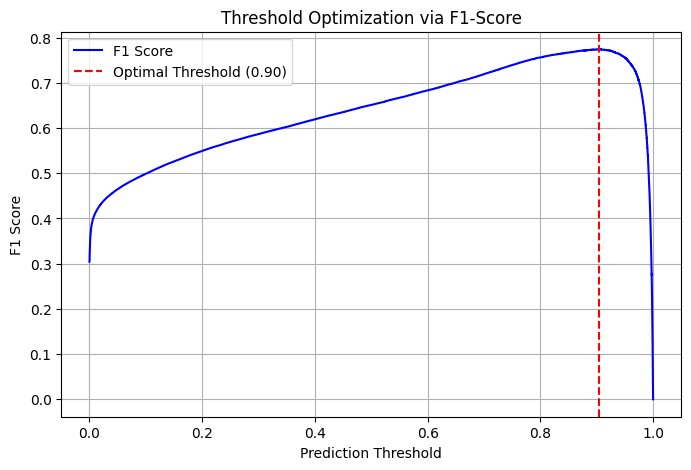


Final Test Metrics (Optimized Threshold):
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95    176855
  Cloudburst       0.77      0.78      0.77     38670

    accuracy                           0.92    215525
   macro avg       0.86      0.86      0.86    215525
weighted avg       0.92      0.92      0.92    215525



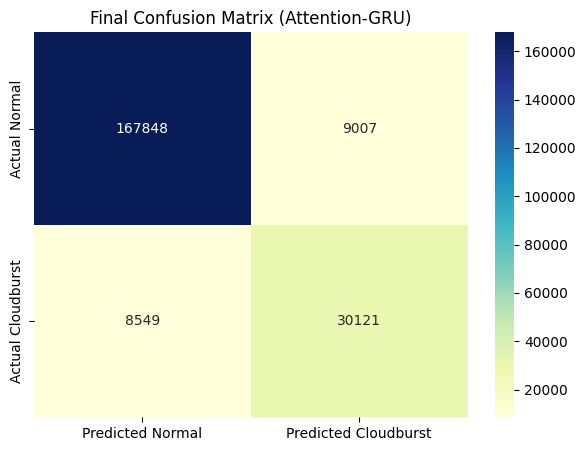

In [9]:
def get_optimal_threshold(model, loader):
    model.eval()
    y_true, y_probs = [], []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            probs = torch.sigmoid(model(batch_x)).squeeze()
            y_probs.extend(probs.cpu().numpy())
            y_true.extend(batch_y.cpu().numpy())

    # Calculate precision-recall curve to find the exact best threshold mathematically
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    # Avoid division by zero
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]

    print(f"Optimal Threshold found: {optimal_threshold:.4f} (Max F1: {f1_scores[optimal_idx]:.4f})")

    # Plot F1 Score vs Threshold
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1_scores[:-1], 'b-', label='F1 Score')
    plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
    plt.xlabel('Prediction Threshold')
    plt.ylabel('F1 Score')
    plt.title('Threshold Optimization via F1-Score')
    plt.legend()
    plt.grid()
    plt.show()

    return optimal_threshold, y_true, y_probs

# Run optimization
optimal_thresh, y_true_test, y_probs_test = get_optimal_threshold(model, val_loader)

# Apply the mathematically proven best threshold
y_pred_test = (np.array(y_probs_test) > optimal_thresh).astype(int)

print("\nFinal Test Metrics (Optimized Threshold):")
print(classification_report(y_true_test, y_pred_test, target_names=['Normal', 'Cloudburst']))

# Plot Final Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_true_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Predicted Normal', 'Predicted Cloudburst'],
            yticklabels=['Actual Normal', 'Actual Cloudburst'])
plt.title('Final Confusion Matrix (Attention-GRU)')
plt.show()

In [10]:
import joblib

# Save the scaler used for normalization
joblib.dump(scaler, 'cloudburst_scaler_attn.pkl')

# Save the final model weights
torch.save(model.state_dict(), 'final_cloudburst_attn_gru.pth')

print("Attention-based Model and Scaler saved successfully. You are ready for deployment!")

Attention-based Model and Scaler saved successfully. You are ready for deployment!
